# #30DayMapChallenge - Día 12: Espacio
## Caso de Negocio: Elegir un sitio en Marte (CRS no terrestre)

**Autor:** Mario Ignacio Ibañez Castro | **Rol:** Data Scientist & Strategic Planner

### El objetivo
Hoy el planeta **no es la Tierra**. Trabajamos el DEM global de Marte (NASA MOLA) en un sistema de coordenadas **planetocéntrico IAU2000** (`+proj=longlat +R=3396190`), no EPSG:4326.

**Pregunta de negocio (espacial):** ¿Dónde aterrizar / emplazar una base? Criterios simples de ingeniería:

- Latitud moderada (energía solar / térmica)
- Elevación no extrema (atmósfera / entrada)
- Pendiente baja (aterrizaje y movilidad)

**Reto técnico:** Sistemas de coordenadas no terrestres + álgebra raster en Marte.

**Fuente:** NASA MGS MOLA MEGDR (PDS / Goddard) — topografía mediana 4 ppd.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
from rasterio.transform import xy
from pathlib import Path
from pyproj import CRS, Transformer

plt.style.use('dark_background')
%matplotlib inline

RUTA = Path('../00_Datos')
OUT = Path('.')
DEM = RUTA / 'mars_mola_dem_4ppd.tif'
SITES = RUTA / 'sitios_marte.csv'

with rasterio.open(DEM) as src:
    dem = src.read(1).astype('float32')
    transform = src.transform
    crs = src.crs
    bounds = src.bounds
    profile = src.profile.copy()

print('CRS Marte:', crs)
print('Shape:', dem.shape, '| elevación:', dem.min(), '…', dem.max(), 'm')
print('Bounds lon/lat (E):', bounds)
sitios = pd.read_csv(SITES)
display(sitios)

CRS Marte: GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",3396190,0]],PRIMEM["Reference meridian",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
Shape: (720, 1440) | elevación: -8068.0 … 21134.0 m
Bounds lon/lat (E): BoundingBox(left=0.0, bottom=-90.0, right=360.0, top=90.0)


/tmp/ipykernel_254004/3589046718.py:19: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  dem = src.read(1).astype('float32')


,nombre,lon_este,lat,tipo
0,Olympus Mons,226.20,18.65,volcan
1,Valles Marineris,290.00,-14.00,canyon
2,Gale Crater (Curiosity),137.40,-5.40,rover
3,Jezero Crater (Perseverance),77.45,18.44,rover
4,Hellás Basin,70.00,-42.40,basin
5,North Pole Cap,0.00,85.00,polo
6,South Pole Cap,0.00,-85.00,polo


### 1. Topografía global de Marte (MOLA)
Elevación relativa al areoide GMM3. Olympus Mons ~21 km; Hellas ~−8 km.

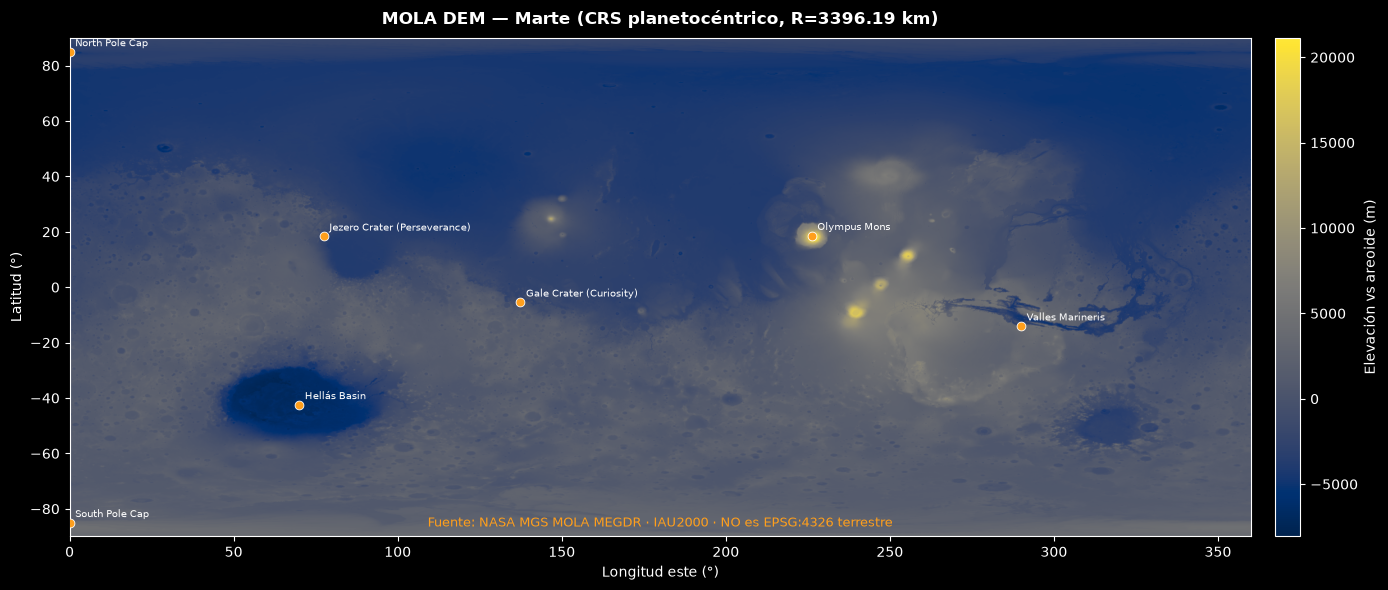

Guardado: Dia12_Mars_DEM.png


In [2]:
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('black')
im = ax.imshow(dem, extent=extent, origin='upper', cmap='cividis', aspect='auto')
cb = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label('Elevación vs areoide (m)', color='white')
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='white')

for _, s in sitios.iterrows():
    ax.scatter(s['lon_este'], s['lat'], c='#FF9F1C', s=40, edgecolors='white', linewidths=0.6, zorder=3)
    ax.annotate(s['nombre'], (s['lon_este'], s['lat']), textcoords='offset points', xytext=(4, 4),
                fontsize=7, color='white', zorder=4)

ax.set_xlabel('Longitud este (°)', color='white')
ax.set_ylabel('Latitud (°)', color='white')
ax.tick_params(colors='white')
ax.set_title('MOLA DEM — Marte (CRS planetocéntrico, R=3396.19 km)', color='white', fontweight='bold', pad=10)
ax.text(0.5, 0.02, 'Fuente: NASA MGS MOLA MEGDR · IAU2000 · NO es EPSG:4326 terrestre',
        transform=ax.transAxes, ha='center', color='#FF9F1C', fontsize=9)
plt.tight_layout()
plt.savefig(OUT/'Dia12_Mars_DEM.png', dpi=170, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia12_Mars_DEM.png')

### 2. ¿En qué se diferencia el CRS?
Comparación explícita Tierra vs Marte: mismo “longlat”, radio distinto ⇒ distancias métricas distintas.

In [3]:
# Distancia geodésica Olympus Mons → Gale sobre esfera de Marte vs si usáramos radio terrestre por error
from pyproj import Geod

geod_mars = Geod(a=3396190, b=3396190)  # esfera marciana
geod_earth = Geod(ellps='WGS84')

o = sitios[sitios['nombre'].str.contains('Olympus')].iloc[0]
g = sitios[sitios['nombre'].str.contains('Gale')].iloc[0]

_, _, d_mars = geod_mars.inv(o['lon_este'], o['lat'], g['lon_este'], g['lat'])
_, _, d_earth = geod_earth.inv(o['lon_este'], o['lat'], g['lon_este'], g['lat'])

print(f"Olympus → Gale")
print(f'  Con radio de Marte:  {d_mars/1000:,.0f} km')
print(f'  Si usáramos WGS84:  {d_earth/1000:,.0f} km  (ERROR de {abs(d_mars-d_earth)/1000:,.0f} km)')
print(f'  Sesgo relativo: {(d_earth/d_mars-1)*100:.1f}%')

# Export insight
pd.DataFrame([{
    'tramo': 'Olympus Mons → Gale Crater',
    'km_marte': d_mars/1000,
    'km_si_wgs84': d_earth/1000,
    'error_km': abs(d_mars-d_earth)/1000,
}]).to_csv(RUTA/'comparacion_crs_distancias.csv', index=False)

Olympus → Gale
  Con radio de Marte:  5,370 km
  Si usáramos WGS84:  10,081 km  (ERROR de 4,711 km)
  Sesgo relativo: 87.7%


### 3. Pendiente planetaria (álgebra de mapas en Marte)
Reproyectamos a equirectangular marciano (metros) para gradientes reales.

Pendiente: 0.00° – 17.29° | media 0.51°


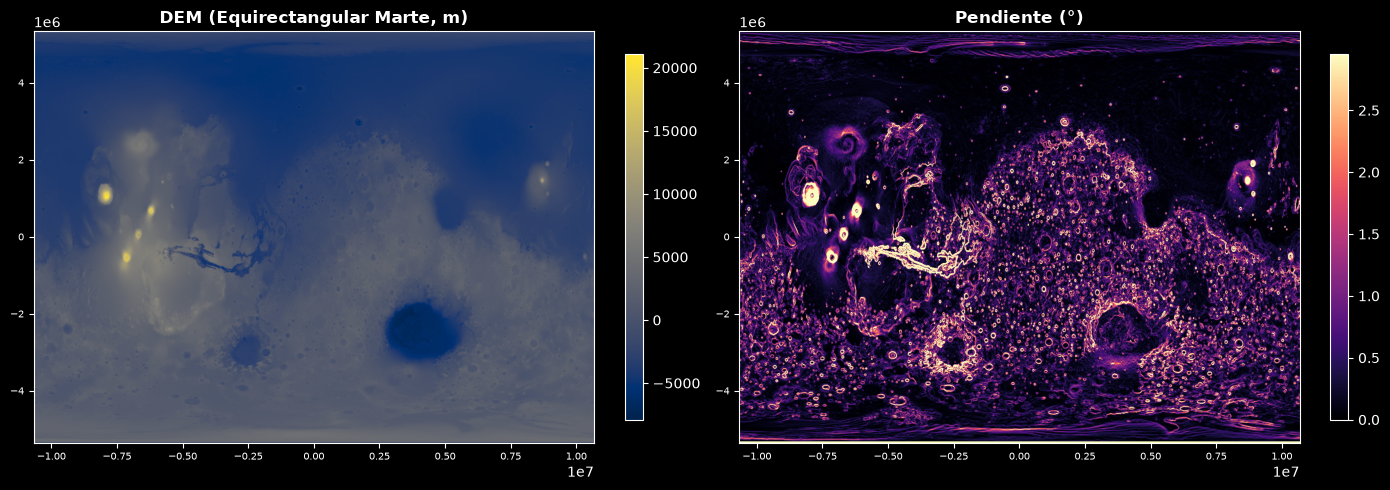

Guardado: Dia12_Mars_Slope.png


In [4]:
from rasterio.warp import calculate_default_transform, reproject, Resampling

mars_eq = CRS.from_proj4('+proj=eqc +lat_ts=0 +lat_0=0 +lon_0=0 +x_0=0 +y_0=0 +R=3396190 +units=m +no_defs +type=crs')

with rasterio.open(DEM) as src:
    t_eq, w_eq, h_eq = calculate_default_transform(src.crs, mars_eq, src.width, src.height, *src.bounds, resolution=15000)
    dem_m = np.empty((h_eq, w_eq), dtype='float32')
    reproject(
        source=rasterio.band(src, 1), destination=dem_m,
        src_transform=src.transform, src_crs=src.crs,
        dst_transform=t_eq, dst_crs=mars_eq,
        resampling=Resampling.bilinear,
    )

dx = abs(t_eq.a); dy = abs(t_eq.e)
dz_dy, dz_dx = np.gradient(dem_m, dy, dx)
slope = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

print(f'Pendiente: {np.nanmin(slope):.2f}° – {np.nanmax(slope):.2f}° | media {np.nanmean(slope):.2f}°')

left, bottom, right, top = rasterio.transform.array_bounds(h_eq, w_eq, t_eq)
extent_m = [left, right, bottom, top]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('black')
im0 = axes[0].imshow(dem_m, extent=extent_m, origin='upper', cmap='cividis', aspect='auto')
axes[0].set_title('DEM (Equirectangular Marte, m)', color='white', fontweight='bold')
plt.colorbar(im0, ax=axes[0], fraction=0.03).ax.yaxis.set_tick_params(color='white')
im1 = axes[1].imshow(slope, extent=extent_m, origin='upper', cmap='magma', vmin=0, vmax=np.nanpercentile(slope, 98), aspect='auto')
axes[1].set_title('Pendiente (°)', color='white', fontweight='bold')
plt.colorbar(im1, ax=axes[1], fraction=0.03).ax.yaxis.set_tick_params(color='white')
for ax in axes:
    ax.tick_params(colors='white', labelsize=7)
plt.tight_layout()
plt.savefig(OUT/'Dia12_Mars_Slope.png', dpi=150, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia12_Mars_Slope.png')

### 4. Máscara de aptitud para base / landing
Reglas de ingeniería (simplificadas):

1. `|lat| ≤ 40°` (banda solar razonable)
2. `−2000 ≤ elev ≤ 2000` m (areoid)
3. `slope ≤ 5°`


In [5]:
# Reproject slope/dem back conceptually using dem_m grid
# Build lat array for each row in geographic DEM for mask, then also show on eqc

# Geographic mask first (cleaner for lat/elev rules)
lons = np.linspace(0.125, 359.875, dem.shape[1])
lats = np.linspace(89.875, -89.875, dem.shape[0])
Lon, Lat = np.meshgrid(lons, lats)

mask_lat = np.abs(Lat) <= 40
mask_elev = (dem >= -2000) & (dem <= 2000)

# Slope on geographic grid approx via reproject nearest
slope_geo = np.empty(dem.shape, dtype='float32')
reproject(
    source=slope, destination=slope_geo,
    src_transform=t_eq, src_crs=mars_eq,
    dst_transform=transform, dst_crs=crs,
    resampling=Resampling.bilinear,
)
mask_slope = slope_geo <= 5
apto = mask_lat & mask_elev & mask_slope

pct = apto.mean() * 100
print(f'Fracción apta: {pct:.1f}% de la superficie mapeada')

# Sample elevaciones en sitios
def sample_dem(lon, lat):
    r, c = rasterio.transform.rowcol(transform, lon, lat)
    if 0 <= r < dem.shape[0] and 0 <= c < dem.shape[1]:
        return float(dem[r, c]), float(slope_geo[r, c])
    return np.nan, np.nan

rows=[]
for _, s in sitios.iterrows():
    e, sl = sample_dem(s['lon_este'], s['lat'])
    ok = (abs(s['lat'])<=40) and (-2000<=e<=2000) and (sl<=5)
    rows.append({**s.to_dict(), 'elev_m': e, 'slope_deg': sl, 'apto': ok})
eval_df = pd.DataFrame(rows)
display(eval_df[['nombre','lat','elev_m','slope_deg','apto']])
eval_df.to_csv(RUTA/'evaluacion_sitios_marte.csv', index=False)

Fracción apta: 23.0% de la superficie mapeada


,nombre,lat,elev_m,slope_deg,apto
0,Olympus Mons,18.65,20009.0,2.069699,False
1,Valles Marineris,-14.00,3361.0,1.149776,False
2,Gale Crater (Curiosity),-5.40,-2927.0,2.379888,False
3,Jezero Crater (Perseverance),18.44,-2478.0,0.944914,False
4,Hellás Basin,-42.40,-5737.0,1.254849,False
5,North Pole Cap,85.00,-4721.0,1.550000,False
6,South Pole Cap,-85.00,3775.0,0.680218,False


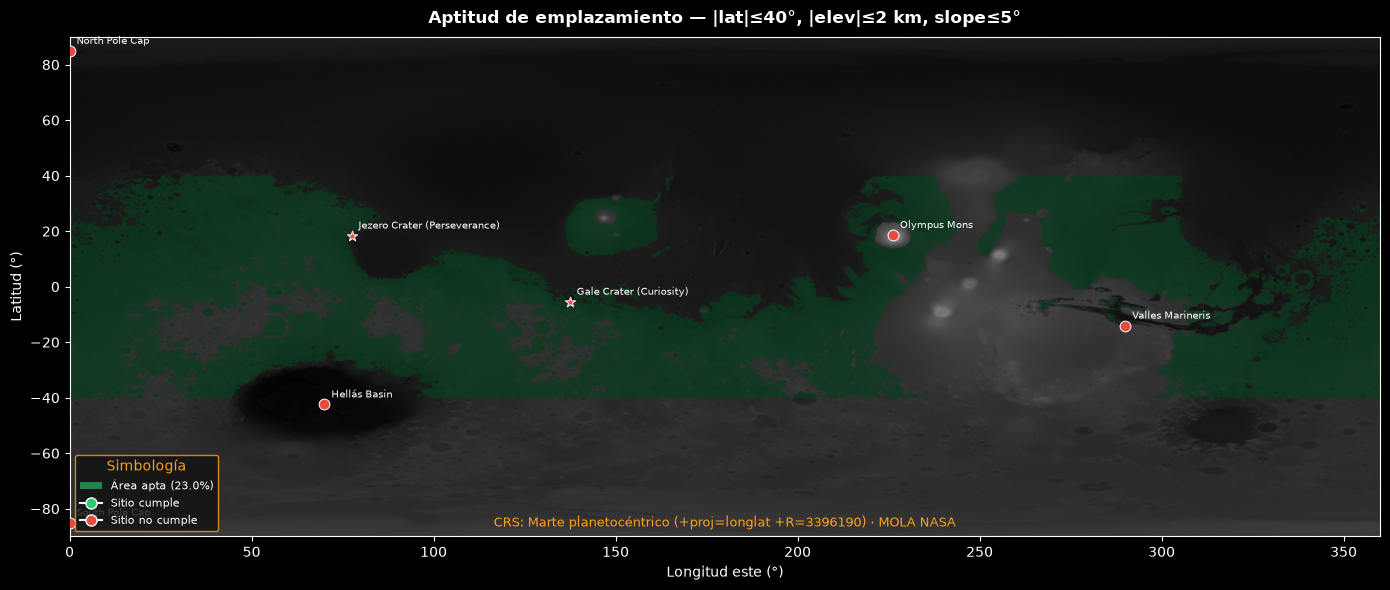

Guardado: Dia12_Mars_Aptitud.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('black')
ax.imshow(dem, extent=extent, origin='upper', cmap='gray', alpha=0.55, aspect='auto')
ax.imshow(np.ma.masked_where(~apto, apto.astype(float)), extent=extent, origin='upper',
          cmap='Greens', alpha=0.55, aspect='auto', vmin=0, vmax=1)

for _, s in eval_df.iterrows():
    color = '#2ECC71' if s['apto'] else '#E74C3C'
    ax.scatter(s['lon_este'], s['lat'], c=color, s=60, edgecolors='white', linewidths=0.7, zorder=4, marker='*' if 'rover' in str(s['tipo']) else 'o')
    ax.annotate(s['nombre'], (s['lon_este'], s['lat']), textcoords='offset points', xytext=(5,5),
                fontsize=7, color='white', zorder=5)

patches = [
    mpatches.Patch(color='#2ECC71', label='Zona apta (mask)'),
    mpatches.Patch(color='#E74C3C', label='Sitio NO apto (reglas)'),
    mpatches.Patch(color='#2ECC71', label='Sitio apto'),
]
# simplify legend
handles = [
    mpatches.Patch(facecolor='#2ECC71', alpha=0.6, label=f'Área apta ({pct:.1f}%)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#2ECC71', markersize=8, label='Sitio cumple'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#E74C3C', markersize=8, label='Sitio no cumple'),
]
leg = ax.legend(handles=handles, loc='lower left', facecolor='#111', edgecolor='#FF9F1C', labelcolor='white', fontsize=8, title='Simbología')
leg.get_title().set_color('#FF9F1C')

ax.set_title('Aptitud de emplazamiento — |lat|≤40°, |elev|≤2 km, slope≤5°', color='white', fontweight='bold', pad=10)
ax.tick_params(colors='white')
ax.set_xlabel('Longitud este (°)', color='white')
ax.set_ylabel('Latitud (°)', color='white')
ax.text(0.5, 0.02, 'CRS: Marte planetocéntrico (+proj=longlat +R=3396190) · MOLA NASA',
        transform=ax.transAxes, ha='center', color='#FF9F1C', fontsize=9)
plt.tight_layout()
plt.savefig(OUT/'Dia12_Mars_Aptitud.png', dpi=170, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia12_Mars_Aptitud.png')

### 5. Panel resumen

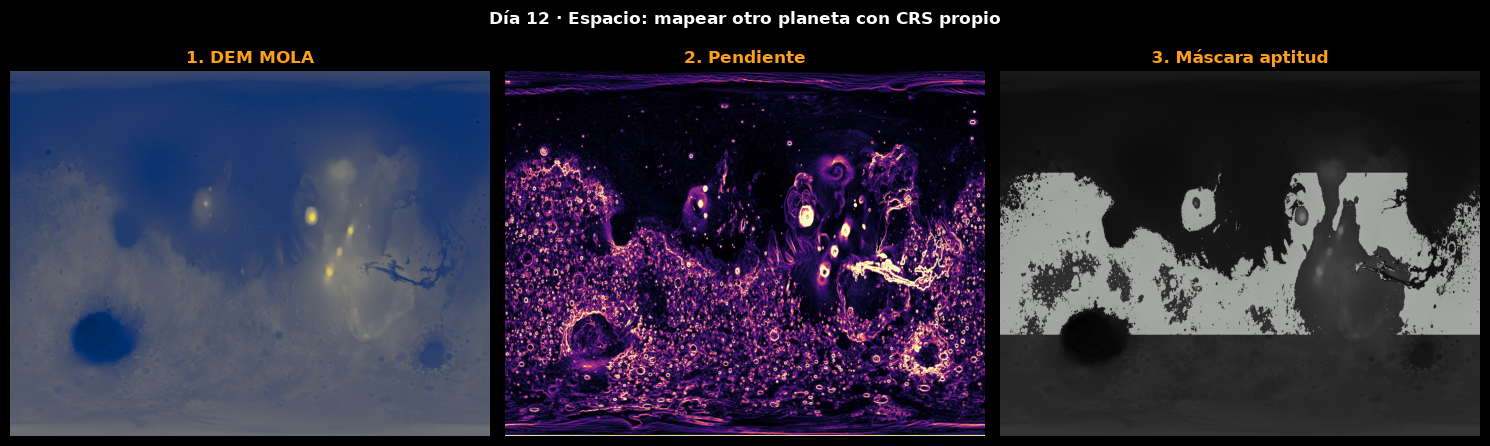

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.patch.set_facecolor('black')
axes[0].imshow(dem, extent=extent, origin='upper', cmap='cividis', aspect='auto')
axes[0].set_title('1. DEM MOLA', color='#FF9F1C', fontweight='bold'); axes[0].set_axis_off()
axes[1].imshow(slope_geo, extent=extent, origin='upper', cmap='magma', vmin=0, vmax=np.nanpercentile(slope_geo, 98), aspect='auto')
axes[1].set_title('2. Pendiente', color='#FF9F1C', fontweight='bold'); axes[1].set_axis_off()
axes[2].imshow(dem, extent=extent, origin='upper', cmap='gray', alpha=0.5, aspect='auto')
axes[2].imshow(np.ma.masked_where(~apto, apto.astype(float)), extent=extent, origin='upper', cmap='Greens', alpha=0.6, aspect='auto')
axes[2].set_title('3. Máscara aptitud', color='#FF9F1C', fontweight='bold'); axes[2].set_axis_off()
fig.suptitle('Día 12 · Espacio: mapear otro planeta con CRS propio', color='white', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT/'Dia12_Panel.png', dpi=150, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

### 6. Insight
- **EPSG:4326 no sirve en Marte.** Usar radio IAU (≈3396 km) o te equivocas en cientos de km.
- El “negocio” espacial (landing / base) se parece al de CDMX: elevación + pendiente + latitud = máscara de candidatos.
- MOLA + CRS planetario es el equivalente marciano de INEGI + EPSG:6362.

### Regenerar
```bash
python ../00_Datos/descargarMOLA.py
```

In [8]:
print('Día 12 completado.')
print(f'CRS: {crs}')
print(f'Área apta: {pct:.1f}%')
print(eval_df[['nombre','apto']].to_string(index=False))

Día 12 completado.
CRS: GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",3396190,0]],PRIMEM["Reference meridian",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
Área apta: 23.0%
                      nombre  apto
                Olympus Mons False
            Valles Marineris False
     Gale Crater (Curiosity) False
Jezero Crater (Perseverance) False
                Hellás Basin False
              North Pole Cap False
              South Pole Cap False
